# LAB2 Частина 4. Оцінка параметрів функції

Виконавець:  <b>Сєров Едуард Олегович</b>, група <b>К-26</b>
<br> Викладач: <b>Ляшко А. В</b>

Знадобляться бібліотеки <code>numpy</code>, <code>scipy</code>, <code>pandas</code>, <code>matplolib</code>.

In [1]:
from pathlib import Path
import numpy as np
import scipy, scipy.linalg as la
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
print(f'numpy {np.__version__}, pandas {pd.__version__}, scipy {scipy.__version__}, matplotlib {matplotlib.__version__}')

numpy 2.4.1, pandas 3.0.0, scipy 1.17.0, matplotlib 3.10.8


### Постановка задачі

У результаті кількох експериментів з обчислення швидкодії програми була отримана низка даних вигляду $(n, t)$, де <br> 
$n$ &mdash; розмір оброблюваних вхідних даних, <br>
$t$ &mdash; кількість часу, що була в середньому необхідна для їх обробки.

Дослідник знає, що часова складність програми повинна мати вигляд $T(n)=\Theta(n^a)$.
Знайти значення параметра $a$.

<i>Зауваження</i>. 
Якщо $T(n)=\Theta(n^a)$, то можна вважати, що $T(n)\approx cn^a$.

На відміну від частини 1, у цій задачі результати експериментів задані у csv-файлі. Кожен рядок файлу містить розмір оброблюваних даних та час роботи на них. Для деяких розмірів виконували кілька експериментів, тому розміри можуть повторюватись. Під час оцінювання параметрів для кожного наявного розміру слід використовувати середнє значення часу роботи.

In [2]:
path = Path('variants/lab2_var090.csv')

Завантажити дані в DataFrame за допомогою функції <code>pd.read_csv</code> (<a href="https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html#pandas-read-csv" target=_blank rel="noopener noreferrer">документація тут</a>).

In [3]:
raw = pd.read_csv(path)

Виконати необхідні перетворення даних засобами <code>pandas</code>

In [4]:
grouped = raw.groupby('n').mean().reset_index()

In [5]:
df_transformed = pd.DataFrame({
    'const': 1.0,
    'ln_n': np.log(grouped['n']),
    'ln_t': np.log(grouped['t'])
})

Побудувати матрицю $data$ (див. LSM.pdf). Має бути багатовимірним масивом типу <code>ndarray</code>.

<details>
    <summary>Підказка.</summary>
    У класі <code>DataFrame</code> є метод <code>to_numpy</code>
</details>

In [6]:
data = df_transformed.to_numpy()
data[:5]

array([[1.        , 2.30258509, 4.39855594],
       [1.        , 3.55534806, 5.97761914],
       [1.        , 3.80666249, 6.27852142],
       [1.        , 4.54329478, 7.38647085],
       [1.        , 4.59511985, 7.56579328]])

In [7]:
X = data[:, :2]
Y = data[:, 2]

In [8]:
beta, _, _, _ = la.lstsq(X, Y)

Знайти оцінки параметрів $a$, $c$ функції $T(n)\approx cn^a$.

In [9]:
a = beta[1]
c = np.exp(beta[0])

In [10]:
print(f'{c = :.6f}, {a = :.6f}')

c = 2.663346, a = 1.432833


#### Візуальна оцінка якості наближення

Для цього побудуємо графік знайденої функції та накладемо на нього вхідні дані.

Побудувати функцію <code>T_estimated</code>, що обчислює чаc роботи програми за формулою $T(n)=cn^a$ з використанням знайдених оцінок  <code>a</code>, <code>c</code> параметрів $a$ та $c$.

In [11]:
def T_estimated(n):
    return c * (n ** a)

Для візуалізації будемо будувати графік поточково, тому потрібні значення в проміжних точках.

Почнемо з того, що визначимо точки, які використаємо в поточковій побудові графіку. Отриманий масив точок, які рівномірно розташовані по всій шкалі, запам'ятаємо в змінній <code>scale</code>.    

In [12]:
scale = np.linspace(raw['n'].min(), raw['n'].max(), 100)

З використанням функції <code>T_estimated</code> обчислимо розрахункові значення функції часової складності на всій шкалі і запам'ятаємо в змінній <code>times</code>.

<details><summary>Підказка.</summary>
Функція <code>T_estimated</code> може бути застосована до масиву <code>scale</code> безпосередньо.</details>

In [13]:
times = T_estimated(scale)

Візуалізуємо отримані результати.

На графіку червоні точки відповідають "експериментальним" даним. Синім зображено графік отриманої залежності часу роботи від розмірів даних. 

$n$ &mdash; масив вхідних розмірів
<br>
$t$ &mdash; масив, що містить значення часу роботи на даних відповідного розміру
<br>
(зміст цих змінних такий самий, що і в частині 1)

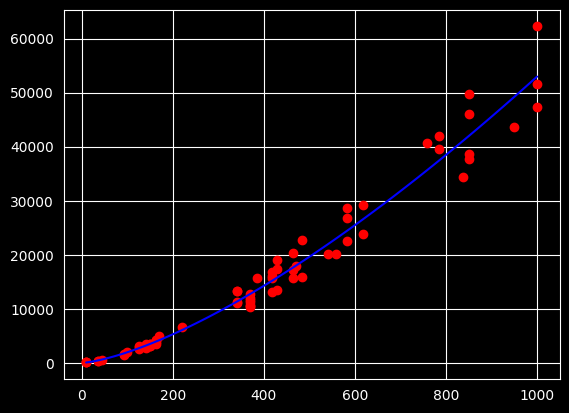

In [14]:
n = raw['n']
t = raw['t']
plt.plot(n, t, color="red", marker='o', linestyle='None')
plt.plot(scale, times, color='blue')
#plt.show()
#plt.savefig('1.png')

## Частину 4 зроблено!